In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
import time

Using exact mode functions and Schwinger parametrization of the shape integrals, this notebook executes the code FastShapes.py and generates figures relevant for phenomenology analysis.

# Check against Known Formula

Below we reproduce Figure 1 of the IAP team letter. The following cell should run in about 1 sec, much faster than the series expression. The colours and the curves in the figure match their results perfectly. Notice that the function build_kernel_table takes as input $(m_{\mathrm{eff}}/H, \rho/H)$.

In [2]:
from FastShapes import build_kernel_table, shape_pidot3, shape_single_parallel, shape_single_perp, shape_double, shape_triple

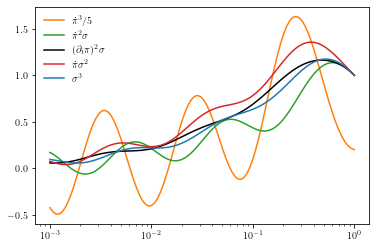

In [3]:
# Parameters
mueff = 3
meff = np.sqrt(mueff**2+9/4)
rho = 3.16227 # this corresponds to the bare mass (m/H)^2=1.25 as in the letter


# Pre-computing the kernel
table = build_kernel_table(meff_over_H=meff, rho_over_H=rho)


# Scanning the squeezed limit
n = 100
kLkS = np.logspace(np.log10(0.001), np.log10(1), n)

S_pidot3 = []
S_single_parallel = []
S_single_perp = []
S_double = []
S_triple = []

for i in range(len(kLkS)):
    S_pidot3.append(shape_pidot3(k1=1.0/kLkS[i], k2=1.0/kLkS[i], k3=1.0, table=table))
    S_single_parallel.append(shape_single_parallel(k1=1.0/kLkS[i], k2=1.0/kLkS[i], k3=1.0, table=table))
    S_single_perp.append(shape_single_perp(k1=1.0/kLkS[i], k2=1.0/kLkS[i], k3=1.0, table=table))
    S_double.append(shape_double(k1=1.0/kLkS[i], k2=1.0/kLkS[i], k3=1.0, table=table))
    S_triple.append(shape_triple(k1=1.0/kLkS[i], k2=1.0/kLkS[i], k3=1.0, table=table))
    
S_pidot3 = np.asarray(S_pidot3)
S_single_parallel = np.asarray(S_single_parallel)
S_single_perp = np.asarray(S_single_perp)
S_double = np.asarray(S_double)
S_triple = np.asarray(S_triple)


# Plot
plt.semilogx(kLkS, S_pidot3/S_pidot3[-1]*kLkS**(-1/2)/5, label = "$\dot\pi^3/5$", c = "C1")
plt.semilogx(kLkS, S_single_parallel/S_single_parallel[-1]*kLkS**(-1/2), label = "$\dot\pi^2\sigma$", c = "C2")
plt.semilogx(kLkS, S_single_perp/S_single_perp[-1]*kLkS**(-1/2), label = "$(\partial_i\pi)^2\sigma$", c = "k")
plt.semilogx(kLkS, S_double/S_double[-1]*kLkS**(-1/2), label = "$\dot\pi\sigma^2$", c = "C3")
plt.semilogx(kLkS, S_triple/S_triple[-1]*kLkS**(-1/2), label = "$\sigma^3$", c = "C0")
plt.legend(frameon = False)

# Full Shapes

Below we compute the full shapes for all interactions at a fixed point $(m_{\mathrm{eff}}/H, \rho/H)$ in parameter space. Depending on the resolution (typically 50 points in each direction), the following cell executes in about 20 sec. The cell computes the full shapes for all interactions, and we have commented out all but one for visualisation.

In [4]:
from FastShapes import build_kernel_table, make_triangle_grid, shape_many_pidot3, shape_many_single_parallel, shape_many_single_perp, shape_many_double, shape_many_triple

In [ ]:
# Parameters
mueff = 2.5
rho = 2.5
meff = np.sqrt(mueff**2+9/4)


# Pre-computing the kernel
table = build_kernel_table(meff_over_H=meff, rho_over_H=rho)


# Computing the shapes
k1s, k2s, k3s = make_triangle_grid(n1=30, n2=30)

S_pidot3_grid = shape_many_pidot3(k1s, k2s, k3s, table)
S_single_parallel_grid = shape_many_single_parallel(k1s, k2s, k3s, table)
S_single_perp_grid = shape_many_single_perp(k1s, k2s, k3s, table)
S_double_grid = shape_many_double(k1s, k2s, k3s, table)
S_triple_grid = shape_many_triple(k1s, k2s, k3s, table)

In [ ]:
x1, x2 = k1s / k3s, k2s / k3s

S_pidot3_norm = S_pidot3_grid / shape_pidot3(1, 1, 1, table)
S_single_parallel_norm = S_single_parallel_grid / shape_single_parallel(1, 1, 1, table)
S_single_perp_norm = S_single_perp_grid / shape_single_perp(1, 1, 1, table)
S_double_norm = S_double_grid / shape_double(1, 1, 1, table)
S_triple_norm = S_triple_grid / shape_triple(1, 1, 1, table)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

#ax.plot_trisurf(x2, x1, S_pidot3_norm, cmap='coolwarm', linewidth=0.1, antialiased=True)
#ax.plot_trisurf(x2, x1, S_single_parallel_norm, cmap='coolwarm', linewidth=0.1, antialiased=True)
ax.plot_trisurf(x2, x1, S_single_perp_norm, cmap='coolwarm', linewidth=0.1, antialiased=True)
#ax.plot_trisurf(x2, x1, S_double_norm, cmap='coolwarm', linewidth=0.1, antialiased=True)
#ax.plot_trisurf(x2, x1, S_triple_norm, cmap='coolwarm', linewidth=0.1, antialiased=True)

ax.set_xlabel('$x_2 = k_2/k_3$', fontsize = 12)
ax.set_ylabel('$x_1 = k_1/k_3$', fontsize = 12)

ax.view_init(elev=25, azim=40)

# Check against CosmoFlow

In [8]:
from Parameters import parameters
from Theory import theory
from Solver import solver

from scipy.special import erf


def erf_adiabatic(N_load, DeltaN, width=0.15):
    """erf (Gaussian CDF) turn-on."""
    N_on = 1 - DeltaN
    return (1 + erf((N_load - N_on) / (width * np.sqrt(2)))) / 2



def Shape(kLkS, params):
    
    n = 10000
    N_load = np.linspace(-10, 20, n)
    DeltaN = 4.5 # Number of e-folds before horizon crossing
    
    k = 1 # Mode corresponding to N = 0 horizon exit
    k1, k2, k3 = k/kLkS, k/kLkS, k
    N_exit = np.log(np.min([k1, k2, k3]))
    
    # Load parameters
    meff = params["meff"]
    rho = params["rho"]
    
    kappa1 = params["kappa1"]
    kappa2 = params["kappa2"]
    
    lambda11 = params["lambda11"]
    lambda12 = params["lambda12"]
    lambda2 = params["lambda2"]
    lambda3 = params["lambda3"]
    
    # Theory 
    m2 = meff**2-rho**2
    H_load = np.ones(n)
    m2_load = m2 * np.ones(n)
    rho_load = rho * np.ones(n) * erf_adiabatic(N_load, DeltaN)

    kappa1_load = kappa1 * np.ones(n) * erf_adiabatic(N_load, DeltaN)
    kappa2_load = kappa2 * np.ones(n) * erf_adiabatic(N_load, DeltaN)

    lambda11_load = lambda11 * np.ones(n) * erf_adiabatic(N_load, DeltaN)
    lambda12_load = lambda12 * np.ones(n) * erf_adiabatic(N_load, DeltaN)
    lambda2_load = lambda2 * np.ones(n) * erf_adiabatic(N_load, DeltaN)
    lambda3_load = lambda3 * np.ones(n) * erf_adiabatic(N_load, DeltaN)
    
    # Load the parameters and define continuous functions
    param = parameters(N_load, H_load, m2_load, rho_load, kappa1_load, kappa2_load, lambda11_load, lambda12_load, lambda2_load, lambda3_load)
    interpolated = param.output()

    # Numerical parameters
    Nspan = np.linspace(-10, 20, 1000) # Time span in e-folds for the numerical integration
    Nfield = 2 # Number of fields
    Rtol, Atol = 1e-3, 1e-100 # Relative and absolute tolerance of the integrator
    Ni, Nf = N_exit - DeltaN, 20 # Sets initial and final time for integration
    N = np.linspace(Ni, Nf, 1000) # Define the time array for output correlators

    # Initialise the integrator
    theo = theory(N = Nspan, Nfield = Nfield, interpolated = interpolated)

    start = time.time()
    s = solver(Nspan = N, Nfield = Nfield, interpolated = interpolated, Rtol = Rtol, Atol = Atol)
    f = s.f_solution(k1 = k1, k2 = k2, k3 = k3)
    end = time.time()
    #print(end - start)

    # Shape function
    S = 1/(2*np.pi)**4/((f[0][0, 0][-1]*k1**3/2/np.pi**2 + f[1][0, 0][-1]*k2**3/2/np.pi**2 + f[2][0, 0][-1]*k3**3/2/np.pi**2)/3)**2 * (k1*k2*k3)**2 * f[6][0, 0, 0]
    
    return S[-1]

In [9]:
from joblib import Parallel, delayed

n = 20
kLkS = np.logspace(np.log10(0.05), np.log10(1), n)


params = {
    "meff": 3,
    "rho": 5,
    "kappa1": 0,
    "kappa2": 0,
    "lambda11": 0,
    "lambda12": 1,
    "lambda2": 0,
    "lambda3": 0,
}


def process(i):
    return Shape(kLkS = kLkS[i], params = params)

start_time = time.time() # Start recording runtime
ShapeScan = Parallel(n_jobs = 6)(delayed(process)(i) for i in range(n)) # n_jobs is the number of cores
print("--- %s seconds ---" % (time.time() - start_time)) # Print runtime


--- 27.305220127105713 seconds ---


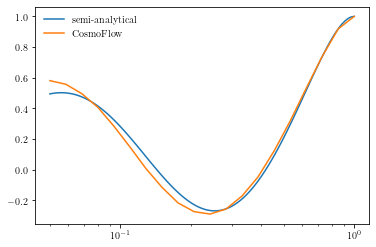

In [10]:
# Pre-compute the kernel
meff = params["meff"]
rho = params["rho"]
table = build_kernel_table(meff_over_H=meff, rho_over_H=rho)

n = 100
k = np.logspace(np.log10(0.05), np.log10(1), n)
shape = []

for i in range(len(k)):
    if params["kappa1"] != 0:
        shape.append(shape_pidot3(k1=1.0/k[i], k2=1.0/k[i], k3=1.0, table=table))
    elif params["lambda11"] != 0:
        shape.append(shape_single_parallel(k1=1.0/k[i], k2=1.0/k[i], k3=1.0, table=table))
    elif params["lambda12"] != 0:
        shape.append(shape_single_perp(k1=1.0/k[i], k2=1.0/k[i], k3=1.0, table=table))
    elif params["lambda2"] != 0:
        shape.append(shape_double(k1=1.0/k[i], k2=1.0/k[i], k3=1.0, table=table))
    elif params["lambda3"] != 0:
        shape.append(shape_triple(k1=1.0/k[i], k2=1.0/k[i], k3=1.0, table=table))
    
shape = np.asarray(shape)

ShapeScan = np.asarray(ShapeScan)

plt.semilogx(k, shape/shape[-1], label = "semi-analytical")
plt.semilogx(kLkS, ShapeScan/ShapeScan[-1], label = "CosmoFlow")
plt.legend(frameon = False)


# Cosine with Equilateral Template

Below we compute the cosine for all the shapes with the equilateral template in the $(\mu_{\mathrm{eff}}/H, \rho/H)$ parameter space. Since the kernels have to be computed at each point, this is expensive/time consuming.

In [ ]:
from FastShapes import scan_cosine_grid_pidot3, scan_cosine_grid_single_parallel, scan_cosine_grid_single_perp, scan_cosine_grid_double, scan_cosine_grid_triple

### No exchange $\dot\pi^3$

In [ ]:
npt = 20 # number of points in each direction for the grid

mu_eff_grid = np.linspace(0.5, 3.0, npt)
lam_grid = np.linspace(0.5, 3.0, npt)

cos_grid_pidot3 = scan_cosine_grid_pidot3(mu_eff_grid, lam_grid, cache_dir='kernel_cache', n_jobs=6)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(0.5, 3)
ax.set_ylim(0.5, 3)

im = ax.pcolormesh(mu_eff_grid, lam_grid, cos_grid_pidot3.T, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')

m_vals = np.linspace(0.5, 3.0, 200)
ax.plot(m_vals, np.sqrt(2.25 + m_vals**2), 'k:', label=r'$m^2=0$')

ax.set_xlabel('$\mu_{\mathrm{eff}}$', fontsize = 12)
ax.set_ylabel('$\\rho/H$', fontsize = 12)

plt.colorbar(im, label = '$\cos(S^{\dot\pi^3},S_{\rm eq})$')
plt.legend(frameon = False)

### Single-exchange parallel $\dot\pi^2\sigma$

In [ ]:
npt = 20

mu_eff_grid = np.linspace(0.5, 2.5, npt)
lam_grid = np.linspace(1.5, 3.0, npt)

cos_grid_single_parallel = scan_cosine_grid_single_parallel(mu_eff_grid, lam_grid, cache_dir='kernel_cache', n_jobs=6)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(0.5, 2.5)
ax.set_ylim(1.5, 3.)

im = ax.pcolormesh(mu_eff_grid, lam_grid, cos_grid_single_parallel.T, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')

m_vals = np.linspace(0.5, 3.0, 200)
ax.plot(m_vals, np.sqrt(2.25 + m_vals**2), 'k:', label=r'$m^2=0$')

ax.set_xlabel('$\mu_{\mathrm{eff}}$', fontsize = 12)
ax.set_ylabel('$\\rho/H$', fontsize = 12)

plt.colorbar(im, label = '$\cos(S^{\dot\pi^2\sigma},S_{\rm eq})$')
plt.legend(frameon = False)

### Single-exchange perp $(\partial_i\pi)^2\sigma$

In [ ]:
npt = 20

mu_eff_grid = np.linspace(0.5, 3.0, npt)
lam_grid = np.linspace(0.5, 3.0, npt)

cos_grid_single_perp = scan_cosine_grid_single_perp(mu_eff_grid, lam_grid, cache_dir='kernel_cache', n_jobs=6)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(0.5, 3.)
ax.set_ylim(0.5, 3.)

im = ax.pcolormesh(mu_eff_grid, lam_grid, cos_grid_single_perp.T, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')

m_vals = np.linspace(0.5, 3.0, 200)
ax.plot(m_vals, np.sqrt(2.25 + m_vals**2), 'k:', label=r'$m^2=0$')

ax.set_xlabel('$\mu_{\mathrm{eff}}$', fontsize = 12)
ax.set_ylabel('$\\rho/H$', fontsize = 12)

plt.colorbar(im, label = '$\cos(S^{(\partial_i\pi)^2\sigma},S_{\rm eq})$')
plt.legend(frameon = False)

### Double-exchange $\dot\pi\sigma^2$

In [ ]:
npt = 20

mu_eff_grid = np.linspace(0.5, 2., npt)
lam_grid = np.linspace(0.5, 2., npt)

cos_grid_double = scan_cosine_grid_double(mu_eff_grid, lam_grid, cache_dir='kernel_cache', n_jobs=6)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(0.5, 2.)
ax.set_ylim(0.5, 2.)

im = ax.pcolormesh(mu_eff_grid, lam_grid, cos_grid_double.T, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')

m_vals = np.linspace(0.5, 3.0, 200)
ax.plot(m_vals, np.sqrt(2.25 + m_vals**2), 'k:', label=r'$m^2=0$')

ax.set_xlabel('$\mu_{\mathrm{eff}}$', fontsize = 12)
ax.set_ylabel('$\\rho/H$', fontsize = 12)

plt.colorbar(im, label = '$\cos(S^{\dot\pi\sigma^2},S_{\rm eq})$')
plt.legend(frameon = False)

### Triple-exchange $\sigma^3$

In [ ]:
npt = 20

mu_eff_grid = np.linspace(1.5, 3., npt)
lam_grid = np.linspace(0.5, 2.5, npt)

cos_grid_triple = scan_cosine_grid_triple(mu_eff_grid, lam_grid, cache_dir='kernel_cache', n_jobs=6)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(1.5, 3)
ax.set_ylim(0.5, 2.5)

im = ax.pcolormesh(mu_eff_grid, lam_grid, cos_grid_triple.T, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')

m_vals = np.linspace(0.5, 3.0, 200)
ax.plot(m_vals, np.sqrt(2.25 + m_vals**2), 'k:', label=r'$m^2=0$')

ax.set_xlabel('$\mu_{\mathrm{eff}}$', fontsize = 12)
ax.set_ylabel('$\\rho/H$', fontsize = 12)

plt.colorbar(im, label = '$\cos(S^{\sigma^3},S_{\rm eq})$')
plt.legend(frameon = False)

# Read Shape Grid

In [ ]:
path = "/Users/deniswerth/Documents/MPP/Projects/ConstrainingStrongMixingPNGs/Shapes/data/"

In [ ]:
from read_planck_grids import load, plot_cosine_map, plot_full_shape

data = load(path + "shapes_50x50_pidot3.npz")
plot_cosine_map(data)
plot_full_shape(data, mu_eff=2.5, rho_over_H=2.5)

In [ ]:
data